In [ ]:
!unzip "/content/drive/MyDrive/digital_knee_x-ray_ds.zip"

Archive:  /content/drive/MyDrive/digital_knee_x-ray_ds.zip
  inflating: MedicalExpert-I/0Normal/NormalG0 (1).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (10).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (100).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (101).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (102).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (103).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (104).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (105).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (106).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (107).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (108).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (109).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (11).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (110).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (111).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (112).png  
  inflating: Medi

In [ ]:
import numpy as np
import pandas as pd
import os
import cv2
import random
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

In [ ]:
def read_data(path, image_size, classes):

    X = []
    y = []

    for label in os.listdir(path):

        try:
            count = 0

            for image in os.listdir(path + '/' + label):

                img = cv2.imread(path + '/' + label + '/' + image)

                img = cv2.resize(img,(image_size,image_size))

                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                X.append(img)
                y.append(classes[label])

                count += 1

                if count == 200:
                    break

        except:
            pass

    return np.array(X), np.array(y)

In [ ]:
knee_classes = {
    '0Normal': 0,
    '1Doubtful': 1,
    '2Mild': 2,
    '3Moderate': 3,
    '4Severe': 4
}

In [ ]:
image_size = 200

x1, y1 = read_data('/content/MedicalExpert-I', image_size, knee_classes)
x2, y2 = read_data('/content/MedicalExpert-II', image_size, knee_classes)

X = np.concatenate((x1, x2))
y = np.concatenate((y1, y2))

X, y = shuffle(X, y, random_state=42)

print("Dataset shape:", X.shape)

Dataset shape: (2000, 200, 200, 3)


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

In [ ]:
x_train = preprocess_input(x_train)
x_test = preprocess_input(x_test)

In [ ]:
y_train = to_categorical(y_train,5)
y_test = to_categorical(y_test,5)

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(x_train)

In [ ]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(200,200,3)
)
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu')(x)

output = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 200, 200,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 206, 206,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 100, 100,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 100, 100,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 100, 100,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 102, 102,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 50, 50,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 50, 50,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 50, 50,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 50, 50,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 50, 50,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 50, 50,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 50, 50,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 50, 50,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 50, 50,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 50, 50,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 50, 50,    │      1,024 │ conv2_block1_3_c

 Total params: 24,769,413 (94.49 MB)

 Trainable params: 15,631,877 (59.63 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    validation_data=(x_test, y_test),
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 64s 818ms/step - accuracy: 0.2540 - loss: 1.6820 - val_accuracy: 0.3860 - val_loss: 1.4694
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 18s 384ms/step - accuracy: 0.3380 - loss: 1.4929 - val_accuracy: 0.4940 - val_loss: 1.3043
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 18s 395ms/step - accuracy: 0.4140 - loss: 1.3782 - val_accuracy: 0.5700 - val_loss: 1.1526
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 396ms/step - accuracy: 0.4867 - loss: 1.2674 - val_accuracy: 0.6200 - val_loss: 1.0390
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 17s 369ms/step - accuracy: 0.5280 - loss: 1.1795 - val_accuracy: 0.6480 - val_loss: 0.9446
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 17s 369ms/step - accuracy: 0.5580 - loss: 1.0983 - val_accuracy: 0.6780 - val_loss: 0.8773
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 17s 366ms/step - accuracy: 0.5960 - loss: 0.9907 - val_accuracy: 0.6780 - val_loss: 0.8468
Epoch 8/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 18s 373ms/step - accuracy: 0.6167 - loss: 0.9376 - val_accu

In [ ]:
model.save('knee_xray_resnet50_model.h5')
print("Model saved successfully as 'knee_xray_model.h5'")

Model saved successfully as 'knee_xray_model.h5'


In [ ]:
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    validation_data=(x_test, y_test),
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 56s 784ms/step - accuracy: 0.2165 - loss: 1.8562 - val_accuracy: 0.3440 - val_loss: 1.5020
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 17s 361ms/step - accuracy: 0.3492 - loss: 1.4867 - val_accuracy: 0.4540 - val_loss: 1.3283
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 348ms/step - accuracy: 0.3932 - loss: 1.4345 - val_accuracy: 0.5440 - val_loss: 1.1787
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 17s 351ms/step - accuracy: 0.4637 - loss: 1.2883 - val_accuracy: 0.5840 - val_loss: 1.0973
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 17s 354ms/step - accuracy: 0.5451 - loss: 1.1626 - val_accuracy: 0.6080 - val_loss: 1.0270
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 346ms/step - accuracy: 0.5781 - loss: 1.0680 - val_accuracy: 0.6380 - val_loss: 0.9533
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 347ms/step - accuracy: 0.6156 - loss: 0.9671 - val_accuracy: 0.6680 - val_loss: 0.8959
Epoch 8/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 348ms/step - accuracy: 0.6310 - loss: 0.9315 - val_accu

In [ ]:
loss, acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", acc)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.9060 - loss: 0.2785
Test Accuracy: 0.906000018119812


16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 304ms/step
Classification Report:
              precision    recall  f1-score   support

     0Normal       0.90      0.92      0.91       114
   1Doubtful       0.82      0.81      0.82        93
       2Mild       0.88      0.86      0.87        87
   3Moderate       0.94      0.96      0.95        92
     4Severe       0.97      0.96      0.97       114

    accuracy                           0.91       500
   macro avg       0.90      0.90      0.90       500
weighted avg       0.91      0.91      0.91       500



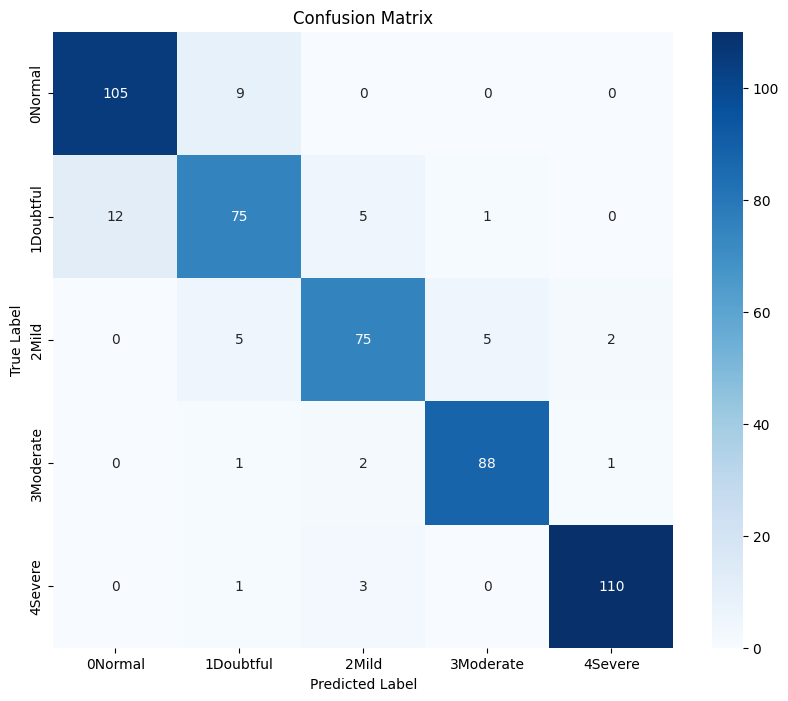

In [ ]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=knee_classes.keys()))

plt.figure(figsize=(10, 8))
sns.heatmap(
    confusion_matrix(y_true_classes, y_pred_classes),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=knee_classes.keys(),
    yticklabels=knee_classes.keys()
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

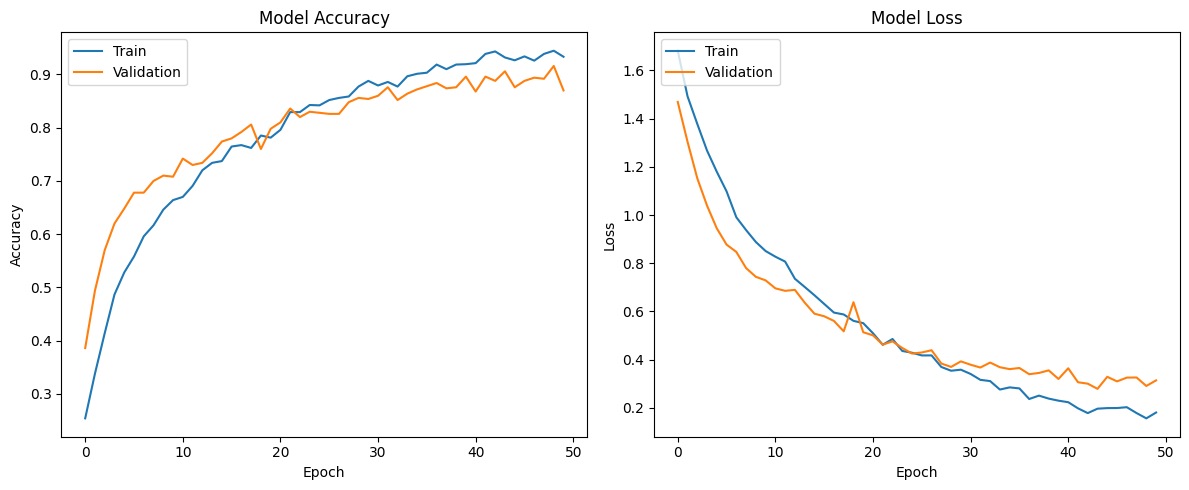

In [ ]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

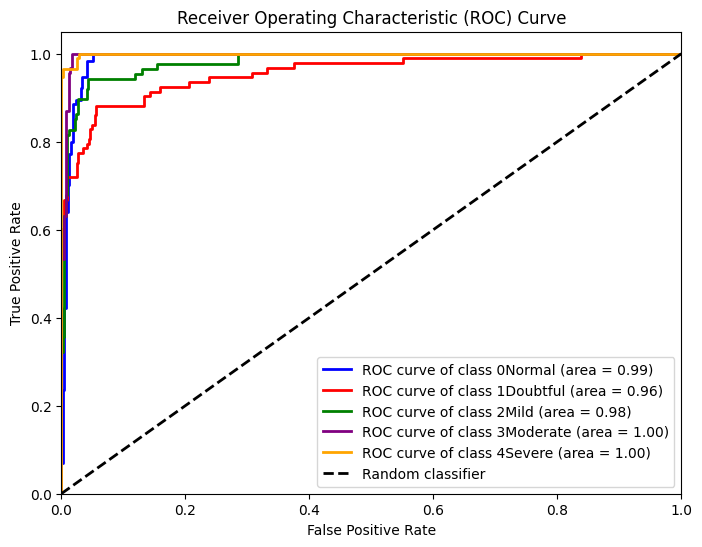

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Compute ROC curve and ROC area for each class
n_classes = len(knee_classes)

# If y_test is one-hot encoded, y_true_classes is needed for roc_curve
# Otherwise, y_test could be used directly if it's label encoded.
# Assuming y_test is one-hot encoded and y_true_classes is the integer label array

# Plot all ROC curves
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'purple', 'orange'] # Define colors for each class

for i, class_name in enumerate(knee_classes.keys()):
    fpr, tpr, _ = roc_curve(y_true_classes, y_pred[:, i], pos_label=i)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'ROC curve of class {class_name} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
!unzip "/content/drive/MyDrive/digital_knee_x-ray_ds.zip"

Archive:  /content/drive/MyDrive/digital_knee_x-ray_ds.zip
  inflating: MedicalExpert-I/0Normal/NormalG0 (1).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (10).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (100).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (101).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (102).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (103).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (104).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (105).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (106).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (107).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (108).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (109).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (11).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (110).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (111).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (112).png  
  inflating: Medi

In [ ]:
import numpy as np
import pandas as pd
import os
import cv2
import random
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

In [ ]:
def read_data(path,image_size,classes):

    X=[]
    y=[]

    for label in os.listdir(path):

        for img_name in os.listdir(os.path.join(path,label)):

            img=cv2.imread(os.path.join(path,label,img_name))
            img=cv2.resize(img,(image_size,image_size))
            img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

            X.append(img)
            y.append(classes[label])

    return np.array(X),np.array(y)

In [ ]:
knee_classes = {
    '0Normal': 0,
    '1Doubtful': 1,
    '2Mild': 2,
    '3Moderate': 3,
    '4Severe': 4
}

In [ ]:
image_size = 200

x1, y1 = read_data('/content/MedicalExpert-I', image_size, knee_classes)
x2, y2 = read_data('/content/MedicalExpert-II', image_size, knee_classes)

X = np.concatenate((x1, x2))
y = np.concatenate((y1, y2))

X, y = shuffle(X, y, random_state=42)

print("Dataset shape:", X.shape)

Dataset shape: (3300, 200, 200, 3)


In [ ]:
import os

dataset_path1 = "/content/MedicalExpert-I"
dataset_path2 = "/content/MedicalExpert-II"

total_images = 0

print("MedicalExpert-I Dataset\n")

for class_name in os.listdir(dataset_path1):

    class_path = os.path.join(dataset_path1, class_name)

    count = len(os.listdir(class_path))

    total_images += count

    print(class_name, ":", count)

print("\nMedicalExpert-II Dataset\n")

for class_name in os.listdir(dataset_path2):

    class_path = os.path.join(dataset_path2, class_name)

    count = len(os.listdir(class_path))

    total_images += count

    print(class_name, ":", count)

print("\nTotal Images in Dataset:", total_images)

MedicalExpert-I Dataset

1Doubtful : 477
0Normal : 514
4Severe : 206
2Mild : 232
3Moderate : 221

MedicalExpert-II Dataset

1Doubtful : 488
0Normal : 503
4Severe : 206
2Mild : 232
3Moderate : 221

Total Images in Dataset: 3300


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

In [ ]:
x_train = preprocess_input(x_train)
x_test = preprocess_input(x_test)

In [ ]:
y_train = to_categorical(y_train,5)
y_test = to_categorical(y_test,5)

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(x_train)

In [ ]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(200,200,3)
)
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu')(x)

output = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 200, 200,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 206, 206,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 100, 100,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 100, 100,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 100, 100,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 102, 102,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 50, 50,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 50, 50,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 50, 50,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 50, 50,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 50, 50,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 50, 50,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 50, 50,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 50, 50,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 50, 50,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 50, 50,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 50, 50,    │      1,024 │ conv2_block1_3_c

 Total params: 24,769,413 (94.49 MB)

 Trainable params: 15,631,877 (59.63 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    validation_data=(x_test, y_test),
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 71s 591ms/step - accuracy: 0.3204 - loss: 1.5509 - val_accuracy: 0.3745 - val_loss: 1.3345
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 28s 359ms/step - accuracy: 0.4360 - loss: 1.2998 - val_accuracy: 0.4945 - val_loss: 1.1360
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 28s 360ms/step - accuracy: 0.5236 - loss: 1.1591 - val_accuracy: 0.6255 - val_loss: 0.9760
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 28s 358ms/step - accuracy: 0.5851 - loss: 1.0237 - val_accuracy: 0.6764 - val_loss: 0.8514
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 28s 360ms/step - accuracy: 0.6331 - loss: 0.9444 - val_accuracy: 0.6933 - val_loss: 0.7589
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 28s 364ms/step - accuracy: 0.6614 - loss: 0.8748 - val_accuracy: 0.7018 - val_loss: 0.7033
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 29s 368ms/step - accuracy: 0.6840 - loss: 0.8201 - val_accuracy: 0.7394 - val_loss: 0.6452
Epoch 8/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 28s 361ms/step - accuracy: 0.7139 - loss: 0.7519 - val_accu

In [ ]:
loss, acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", acc)

26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.9333 - loss: 0.2298
Test Accuracy: 0.9333333373069763


26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 243ms/step
Classification Report:
              precision    recall  f1-score   support

     0Normal       0.95      0.96      0.95       268
   1Doubtful       0.91      0.91      0.91       214
       2Mild       0.90      0.87      0.89       118
   3Moderate       0.96      0.96      0.96       120
     4Severe       0.94      0.96      0.95       105

    accuracy                           0.93       825
   macro avg       0.93      0.93      0.93       825
weighted avg       0.93      0.93      0.93       825



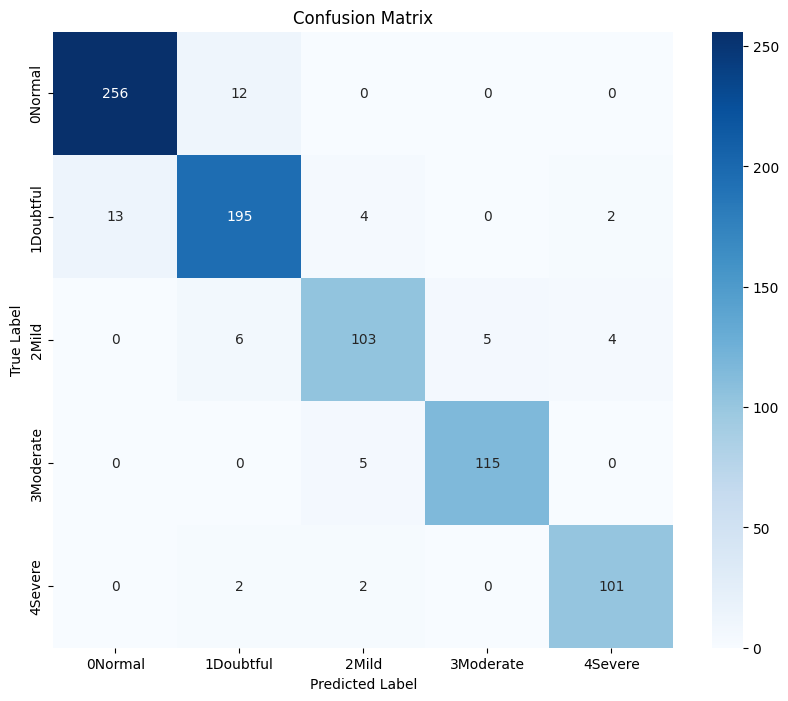

In [ ]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=knee_classes.keys()))

plt.figure(figsize=(10, 8))
sns.heatmap(
    confusion_matrix(y_true_classes, y_pred_classes),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=knee_classes.keys(),
    yticklabels=knee_classes.keys()
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

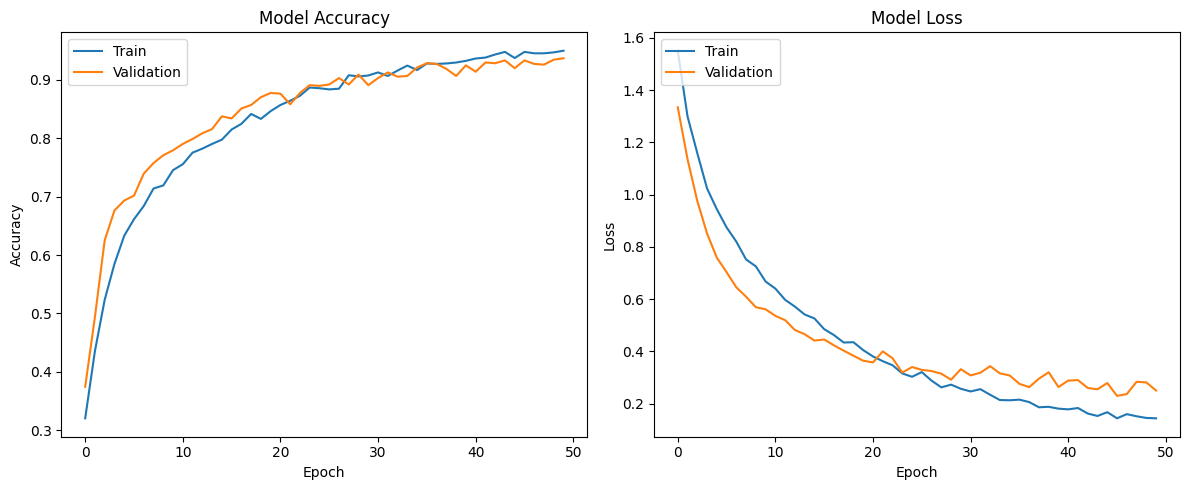

In [ ]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

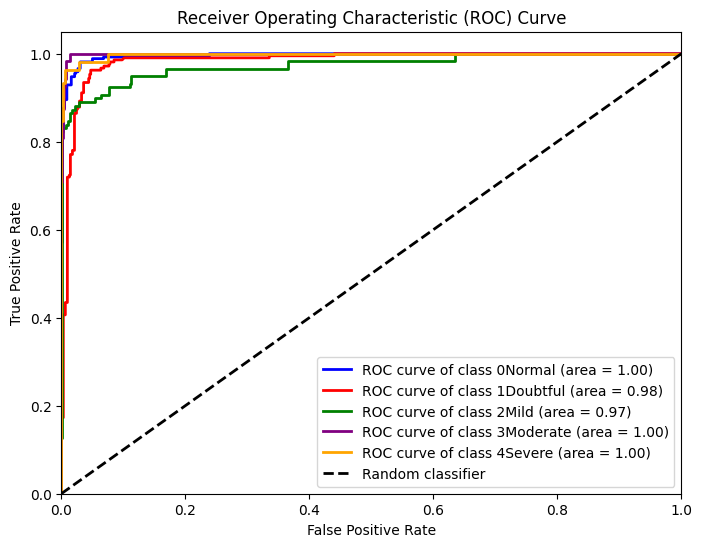

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Compute ROC curve and ROC area for each class
n_classes = len(knee_classes)

# If y_test is one-hot encoded, y_true_classes is needed for roc_curve
# Otherwise, y_test could be used directly if it's label encoded.
# Assuming y_test is one-hot encoded and y_true_classes is the integer label array

# Plot all ROC curves
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'purple', 'orange'] # Define colors for each class

for i, class_name in enumerate(knee_classes.keys()):
    fpr, tpr, _ = roc_curve(y_true_classes, y_pred[:, i], pos_label=i)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'ROC curve of class {class_name} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
model.save('knee_xray_resnet50final_model.h5')
print("Model saved successfully as 'knee_xray_model.h5'")

Model saved successfully as 'knee_xray_model.h5'
